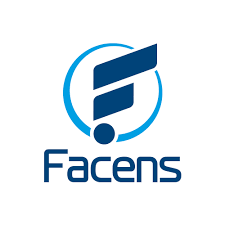
</p>

<br/>
  
<font size="3"><center>Prof. Julio Cesar Mastrodomenico</center></font>




# Aprendizado de Máquinas
### 2023PGS2M2
----

## <center> Análise dos Componentes Principais </center>

Implementação e utilização da Análise dos Componentes Principais

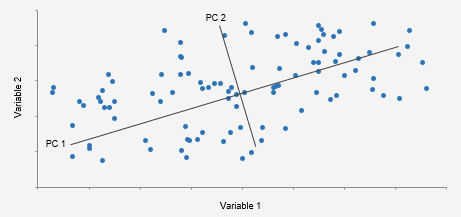

Banco de dados:
- winedataset-red.csv
- Digits
- Iris Dataset


### Exercícios

## 1) Importando as bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, \
                            f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import datasets
import random

# Lib de hoje
from sklearn.decomposition import PCA

# Nossos Algoritmos
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [ ]:
# Importa o dataset do Iris direto do sklearn
loadiris = datasets.load_iris(as_frame=True)
df_iris = pd.concat((pd.DataFrame(loadiris.data),pd.DataFrame(loadiris.target)), axis=1)

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [ ]:
# Visualizando nosso Dataset
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_iris.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
Y = df_iris.iloc[:, -1].values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

X: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Y: [0 0 0 0 0]


# Passo a Passo do algoritmo PCA

#### 1 - Normalizar
#### 2 - Calcular a matriz de covariância
#### 3 - Realizar o SVD (Single Value Decomposition)
#### 4 - Escolher os k primeiros componentes
#### 5 - Projetar X no novo espaço

In [ ]:
# Normalização dos dados por padronização
sc = StandardScaler()
X_norm = sc.fit_transform(X)

In [ ]:
# Visualizando o X_norm
X_norm

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [ ]:
# Uma demonstração do que acontece dentro da função Standard Scaler
(X-X.mean(axis=0))/X.std(axis=0, ddof=1)

array([[-8.97673879e-01,  1.01560199e+00, -1.33575163e+00,
        -1.31105215e+00],
       [-1.13920048e+00, -1.31538812e-01, -1.33575163e+00,
        -1.31105215e+00],
       [-1.38072709e+00,  3.27317509e-01, -1.39239929e+00,
        -1.31105215e+00],
       [-1.50149039e+00,  9.78893485e-02, -1.27910398e+00,
        -1.31105215e+00],
       [-1.01843718e+00,  1.24503015e+00, -1.33575163e+00,
        -1.31105215e+00],
       [-5.35383973e-01,  1.93331463e+00, -1.16580868e+00,
        -1.04866679e+00],
       [-1.50149039e+00,  7.86173830e-01, -1.33575163e+00,
        -1.17985947e+00],
       [-1.01843718e+00,  7.86173830e-01, -1.27910398e+00,
        -1.31105215e+00],
       [-1.74301699e+00, -3.60966973e-01, -1.33575163e+00,
        -1.31105215e+00],
       [-1.13920048e+00,  9.78893485e-02, -1.27910398e+00,
        -1.44224482e+00],
       [-5.35383973e-01,  1.47445831e+00, -1.27910398e+00,
        -1.31105215e+00],
       [-1.25996379e+00,  7.86173830e-01, -1.22245633e+00,
      

In [ ]:
# Calculando a Matriz de covariância
mat_cov = np.cov(X_norm.T)
print(mat_cov)

[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [ ]:
# Realizando o Single Value Decomposition
[U, S, V] = np.linalg.svd(mat_cov)

In [ ]:
# Matriz U
U

array([[-0.52106591, -0.37741762,  0.71956635,  0.26128628],
       [ 0.26934744, -0.92329566, -0.24438178, -0.12350962],
       [-0.5804131 , -0.02449161, -0.14212637, -0.80144925],
       [-0.56485654, -0.06694199, -0.63427274,  0.52359713]])

In [ ]:
# Vetor S, com os single values
S

array([2.93808505, 0.9201649 , 0.14774182, 0.02085386])

In [ ]:
# Visualizando a variância para entender a % explicada com os autovalores
100*S/S.sum()

array([72.96244541, 22.85076179,  3.66892189,  0.51787091])

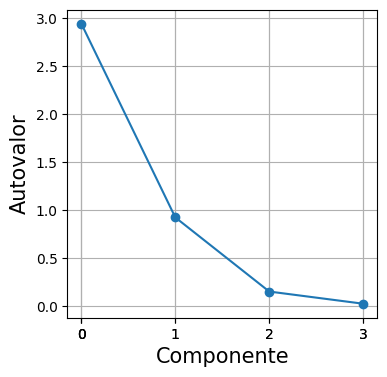

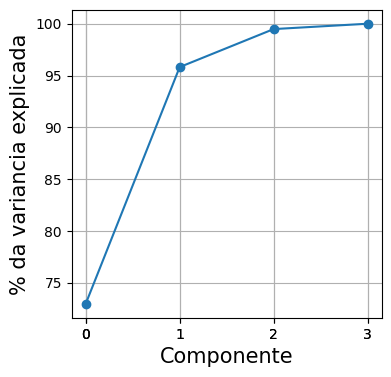

In [ ]:
# Análise dos Componentes

def component_analysis(e, plot='none'):
    varexp = 100* e/e.sum()
    cumvarexp = np.cumsum(varexp)

    # Plotando os autovalores
    if (plot=='eigen'):
        plt.figure(figsize = (4,4))
        plt.plot(e, '-o')
        plt.grid(True)
        plt.xlabel('Componente', fontsize = 15)
        plt.ylabel('Autovalor', fontsize = 15)
        xint = []
        locs, labels = plt.xticks()
        for each in locs:
            xint.append(int(each))
        plt.xticks(xint)

    # Plotando a explicação da variancia
    if (plot=='varexp'):
        plt.figure(figsize = (4,4))
        plt.plot(cumvarexp, '-o')
        plt.xlabel('Componente', fontsize = 15)
        plt.ylabel('% da variancia explicada', fontsize = 15)
        plt.grid(True)
        xint = []
        locs, labels = plt.xticks()
        for each in locs:
            xint.append(int(each))
        plt.xticks(xint)

    plt.show()

# Visualização - plot=['eigen', 'varexp']
component_analysis(S, plot='eigen')
component_analysis(S, plot='varexp')

In [ ]:
# Selecionando os componentes
# Baseando nos autovalores, selecionamos os k primeiros componentes
k = 2
maiores_valores = S.argsort()[::-1][:k]
print(maiores_valores)

[0 1]


In [ ]:
# Dos argumentos com maior valor, pegamos os componentes da Matriz V
princip_comp = U[:, maiores_valores]
print(princip_comp)

[[-0.52106591 -0.37741762]
 [ 0.26934744 -0.92329566]
 [-0.5804131  -0.02449161]
 [-0.56485654 -0.06694199]]


In [ ]:
# Visualizando as dimensões das matrizes X e dos Principais Componentes escolhidos
print(X.shape)
print(princip_comp.shape)

(150, 4)
(4, 2)


In [ ]:
# Calculando a matriz projetada
X_proj = X.dot(princip_comp)

In [ ]:
X_proj

array([[-2.64026976, -5.2040413 ],
       [-2.6707303 , -4.66690995],
       [-2.45460631, -4.77363639],
       [-2.54551709, -4.64846339],
       [-2.56122842, -5.2586291 ],
       [-2.97594579, -5.70732073],
       [-2.4631572 , -4.92969712],
       [-2.67313922, -5.07641913],
       [-2.43713208, -4.38587157],
       [-2.64535121, -4.75499447],
       [-2.80076135, -5.50437488],
       [-2.62696735, -5.00338477],
       [-2.56213805, -4.62247398],
       [-2.12748116, -4.42641769],
       [-2.75425956, -5.92498314],
       [-2.88150922, -6.27729552],
       [-2.74378055, -5.69752408],
       [-2.69675541, -5.2107355 ],
       [-3.10271466, -5.72152225],
       [-2.67399249, -5.49017336],
       [-2.9976482 , -5.2322845 ],
       [-2.75741289, -5.40453799],
       [-2.12063682, -5.09786541],
       [-3.03772014, -5.04681224],
       [-2.80109128, -5.01073225],
       [-2.83891951, -4.70955003],
       [-2.84415184, -5.09225669],
       [-2.75041766, -5.24423222],
       [-2.71931109,

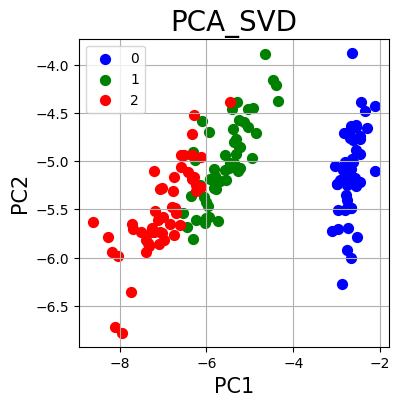

In [ ]:
# Plotting 2D data
def plot_data(X,Y,axis='none', title='none'):
    nrow, ncol = X.shape
    colors = list(plt.rcParams['axes.prop_cycle'])
    colors_plot = {0:'b', 1:'g', 2:'r', 3:'m', 4:'c', 5:'y', 6:'k'}
    ys = list()
    for t in [0,1,2]:
        ys.append(np.argwhere(Y==t))
    if (ncol==2):
        plt.figure(figsize = (4,4))
        for nums in range(len(ys)):
            plt.scatter(X[ys[nums],0], X[ys[nums],1], color=colors_plot[nums], s = 50)
        if (title!='none'):
            plt.title(title, fontsize = 20)
        if (axis!='none'):
            plt.xlabel(axis+'1', fontsize = 15)
            plt.ylabel(axis+'2', fontsize = 15)
        plt.legend([0,1,2])
        plt.grid(True)


plot_data(X_proj, Y, 'PC', 'PCA_SVD')

In [ ]:
#Initializing the PCA Class
class PCA_J():

    #Class responsible for the PCA initialization
    def __init__(self, norm=True, components = None):
        self.mean = None
        self.components = components
        self.norm = norm # Initialize the norm attribute


    # Normalizando os dados
    def normalize(self, X):
        sc = StandardScaler()
        X_norm = sc.fit_transform(X)
        return X_norm

    def fit(self, X):
      if self.norm:
        X_norm = X
      else:
        X_norm = self.normalize(X)

    # Calculando a Matriz de covariancia
      mat_cov = np.cov(X_norm.T)

    # Realiznando o Single Value Decomposition
      self.U, self.S, self.V = np.linalg.svd(mat_cov)

    # Selecionando os k primeiros componentes
      self.princip_comp = self.U[:, :self.components]

    # Calculando a matriz projetada
      self.X_proj = X.dot(self.princip_comp)

    # Transformando os dados
    def transform(self, A):
        return A.dot(self.princip_comp)

In [ ]:
# Instânciando e treinando nosso PCA
pca_cust = PCA_J(components = 2)


In [ ]:
pca_cust.fit(X)

In [ ]:
pca_cust.S  # Now you can access the 'S' attribute

array([4.22824171, 0.24267075, 0.0782095 , 0.02383509])

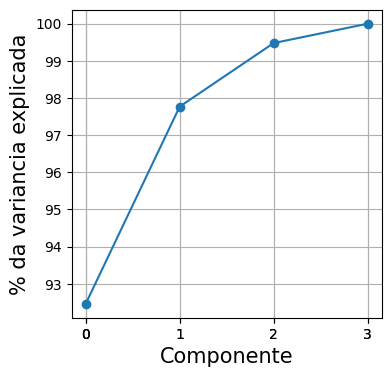

In [ ]:
component_analysis(pca_cust.S, plot='varexp')

In [ ]:
X_norm = sc.fit_transform(X)
X_norm_proj = pca_cust.transform(X_norm)

In [ ]:
X_norm_proj[:2]

array([[ 2.03106506, -0.48431026],
       [ 2.0213579 ,  0.51520868]])

In [ ]:
# Dividindo em Train Test
X_train, X_test, y_train, y_test = train_test_split(X_norm_proj, Y, test_size=0.2, random_state=42)

In [ ]:
# Importar a classe e realizar o predict nos novos dados projetos em 2D
gn = GaussianNB()



# Treino KNN (armazenamento)
gn.fit(X_train, y_train)

# Calcular a acurácia do modelo nos dados de teste
y_pred = gn.predict(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)



# Treino KNN (armazenamento)
knn.fit(X_train, y_train)
accuracy_score(y_test, knn.predict(X_test))

0.9666666666666667

## Comparando com o dataset sem projeção

In [ ]:
# Carregando o dataset
iris = datasets.load_iris(as_frame=True)

In [ ]:
# Visualizando os dados
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


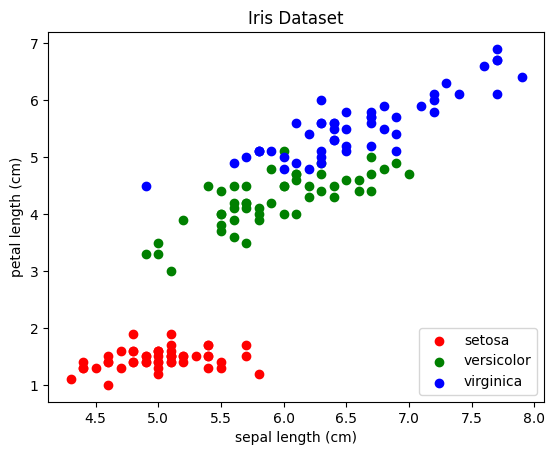

In [ ]:
# Plot de visualização dos dados com apenas 2 caracteristicas
n_samples = len(iris.target)
for t in set(iris.target):
    x = [iris.data.iloc[i,0] for i in range(n_samples) if iris.target[i]==t]
    y = [iris.data.iloc[i,2] for i in range(n_samples) if iris.target[i]==t]
    plt.scatter(x,
                y,
                color=['red', 'green', 'blue'][t],
                label=iris.target_names[t])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title('Iris Dataset')
plt.legend(iris.target_names, loc='lower right')
plt.show()

In [ ]:
X_norm = sc.fit_transform(X)
X_norm_proj_p = pca_cust.transform(X_norm)

In [ ]:
X_norm_proj_p[:2]

array([[ 2.03106506, -0.48431026],
       [ 2.0213579 ,  0.51520868]])

In [ ]:
# Novo split com os dados projetado
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_norm_proj_p, iris.target, test_size=0.2, random_state=0)


In [ ]:
# Importar a classe e realizar o predict nos novos dados projetos em 2D
gn_s = GaussianNB()



# Treino KNN (armazenamento)
gn_s.fit(X_train, y_train)

# Calcular a acurácia do modelo nos dados de teste
accuracy_score(y_test, gn_s.predict(X_test))

0.9666666666666667

In [ ]:
# Importar a classe e realizar o predict nos novos dados projetos em 2D
knn_s = KNeighborsClassifier(n_neighbors=3)



# Treino KNN (armazenamento)
knn_s.fit(X_train, y_train)
# Calcular a acurácia do modelo nos dados de teste
accuracy_score(y_test, knn_s.predict(X_test))

0.9666666666666667

## Visualizando a superfície de decisão, agora possível em 2D

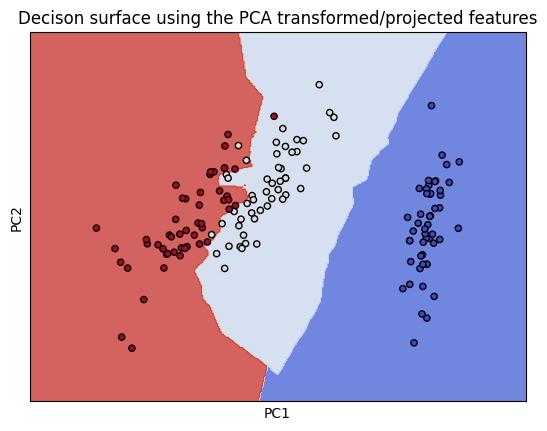

In [ ]:
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

y = iris.target
fig, ax = plt.subplots()

# Set-up grid for plotting.
X0, X1 = X_norm_proj[:, 0], X_norm_proj[:, 1] # Atenção aos dados projetados
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, knn_s, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('PC2')
ax.set_xlabel('PC1')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Decison surface using the PCA transformed/projected features')
plt.show()

<ipython-input-39-9f049435ad9b>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


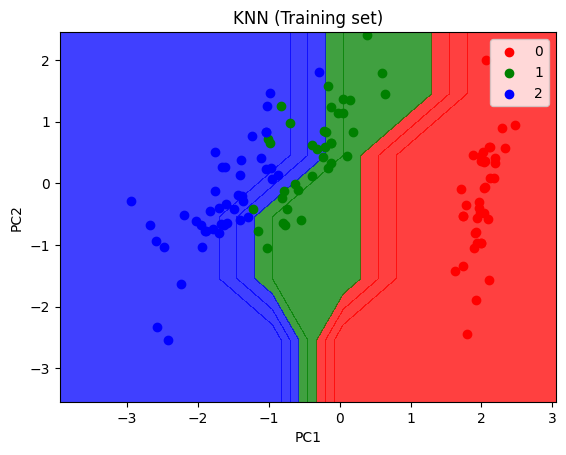

In [ ]:
# Visualizando os resultados da outra forma
from matplotlib.colors import ListedColormap
X_set, y_set = X_train_p, y_train_p
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 1),
                   np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 1))
plt.contourf(X1, X2, knn.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('KNN (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

<ipython-input-40-9877839d3b70>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


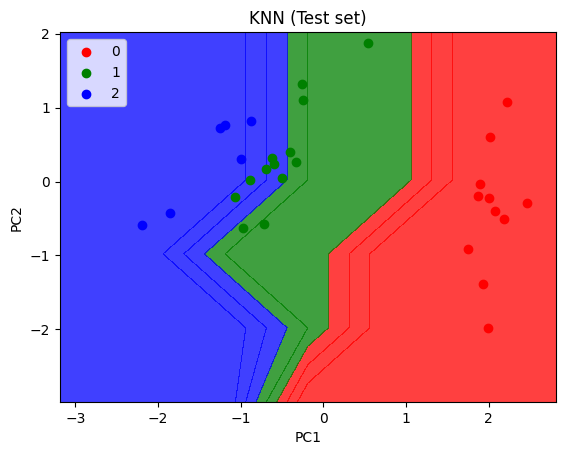

In [ ]:
# Resultado no teste
from matplotlib.colors import ListedColormap
X_set, y_set = X_test_p, y_test_p
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 1))
plt.contourf(X1, X2, knn.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('KNN (Test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## Exercício dataset Wine ( direto do sklearn )

$ from sklearn import datasets

$ wine = datasets.load_wine()

In [ ]:
# Carregando o dataset
wine = datasets.load_wine(as_frame=True)

In [ ]:
wine.data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
wine.target.value_counts()

,count
target,
1,71
0,59
2,48


In [ ]:
X = wine.data
y = wine.target

In [ ]:
sc = StandardScaler()
X_norm = sc.fit_transform(X)

In [ ]:
# Aplicando PCA

pca = PCA()
X_pca = pca.fit(X_norm)



In [ ]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

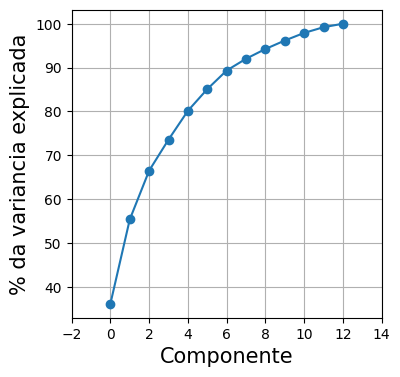

In [ ]:
component_analysis(pca.explained_variance_ratio_, plot='varexp')

## Visualização do dataset dos dígitos com PCA e K-Means

In [ ]:
pca_novo = PCA(n_components=0.5)


In [ ]:
X_pca = pca_novo.fit_transform(X_norm)

In [ ]:
X_pca.shape

(178, 2)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=0)

model_gaussian = GaussianNB()
model_gaussian.fit(X_train, y_train)

model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)

y_gaussian = model_gaussian.predict(X_test)
y_knn = model_knn.predict(X_test)

print(f'Knn: {accuracy_score(y_test, y_knn)}')
print(f'Gaussian: {accuracy_score(y_test, y_gaussian)}')

Knn: 0.9722222222222222
Gaussian: 0.9722222222222222


In [ ]:
print(classification_report(y_test, y_knn))
print(classification_report(y_test, y_gaussian))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00         6

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00         6

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



# Visualizando do dataset dos digitos com PCA e K-Means

In [ ]:
d_digits = datasets.load_digits(as_frame = True)

In [ ]:
d_digits['data']

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [ ]:
d_digits['target'][788]

2

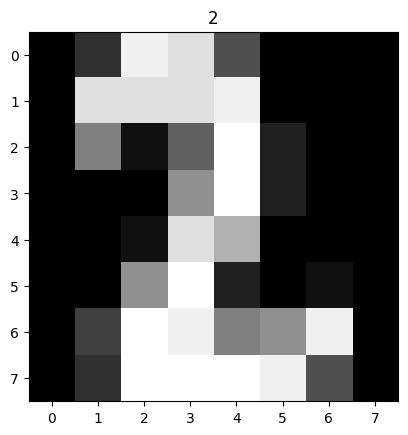

In [ ]:
linha = 788
d1 = d_digits.data.iloc[linha, :].values
im_d1 = d1.reshape(8,8)
plt.imshow(im_d1, cmap='gray')
plt.title(d_digits.target[linha])
plt.show()

In [ ]:
pca_var = PCA()
pca_var.fit(d_digits.data)

PCA()

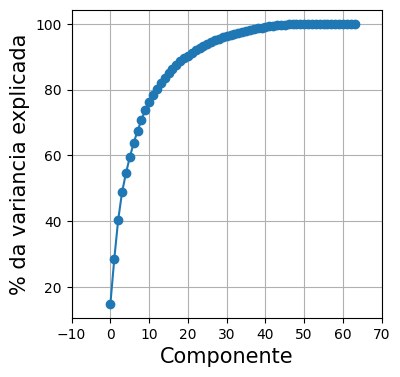

In [ ]:
component_analysis(pca_var.explained_variance_ratio_, plot='varexp')

In [ ]:
d_reduzido = PCA(n_components = 2).fit_transform(d_digits.data)

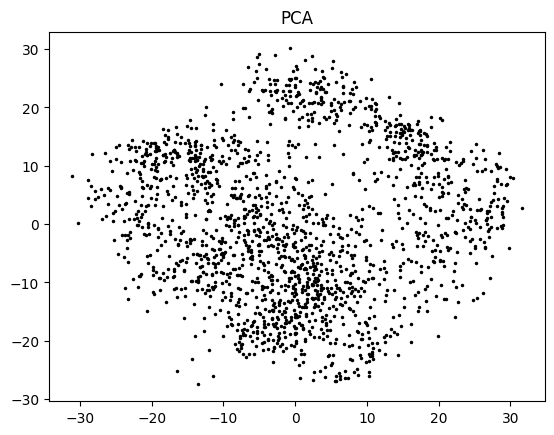

In [ ]:
plt.plot(d_reduzido[:, 0], d_reduzido[:, 1], 'k.', markersize = 3)
plt.title('PCA')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=10)
kmeans.fit(d_reduzido)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=10)

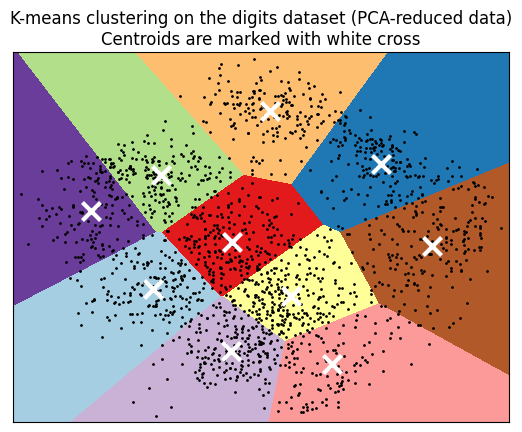

In [ ]:


# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = d_reduzido[:, 0].min() - 1, d_reduzido[:, 0].max() + 1
y_min, y_max = d_reduzido[:, 1].min() - 1, d_reduzido[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(d_reduzido[:, 0], d_reduzido[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()

In [ ]:
preds = kmeans.predict(d_reduzido)

In [ ]:
preds == 5

array([ True, False, False, ..., False, False, False])

In [ ]:
tgs = d_digits['target'].values

In [ ]:
tgs[preds == 0]

array([2, 3, 3, 3, 3, 3, 3, 9, 2, 3, 2, 2, 3, 3, 2, 2, 3, 2, 3, 3, 3, 3,
       3, 2, 9, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 9, 2, 2, 2, 5, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 3,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 8, 2, 3, 3, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 9, 2, 2, 2, 2, 9, 2, 8, 2, 2, 2, 8, 9,
       2, 2, 2, 5, 2, 2, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 2, 7, 2, 3, 2,
       2, 3, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 9, 3, 2, 2,
       3, 2, 3, 3, 3, 2, 9, 2, 8, 2, 2, 3, 2, 2, 3, 2, 3, 3, 3, 2, 2])

In [ ]:
from collections import Counter
Counter(tgs[preds == 2]).most_common(1)[0][0]


9

In [ ]:
for i in range(10):
  cl = Counter(tgs[preds == i]).most_common(1)[0][0]
  print(f'Cluster {i} -> {cl}')

Cluster 0 -> 2
Cluster 1 -> 6
Cluster 2 -> 9
Cluster 3 -> 1
Cluster 4 -> 8
Cluster 5 -> 0
Cluster 6 -> 7
Cluster 7 -> 3
Cluster 8 -> 8
Cluster 9 -> 4


## Exercício de reconstrução de imagem utilizando k componentes

In [ ]:
# Armazenando a imagem
img1 = plt.imread('/content/imagem_1.jpg')

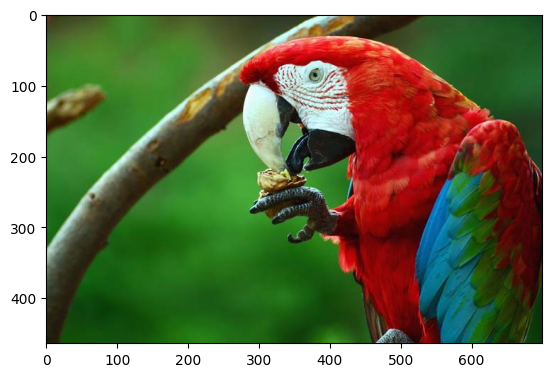

In [ ]:
# Visualizando a imagem
plt.imshow(img1)

array([[[144,  56,  34],
        [139,  59,  34],
        [128,  64,  37],
        ...,
        [ 23,  74,  33],
        [ 23,  74,  33],
        [ 23,  74,  33]],

       [[145,  54,  33],
        [138,  58,  35],
        [128,  62,  36],
        ...,
        [ 23,  74,  33],
        [ 23,  74,  33],
        [ 23,  74,  33]],

       [[143,  51,  30],
        [137,  55,  33],
        [128,  61,  35],
        ...,
        [ 23,  74,  33],
        [ 23,  74,  33],
        [ 23,  74,  33]],

       ...,

       [[ 31,  32,  14],
        [ 30,  31,  13],
        [ 29,  30,  12],
        ...,
        [ 11,  54,   9],
        [ 11,  54,  11],
        [ 11,  54,  11]],

       [[ 31,  32,  14],
        [ 30,  31,  13],
        [ 29,  30,  12],
        ...,
        [ 11,  54,   9],
        [ 11,  54,  11],
        [ 11,  54,  11]],

       [[ 31,  32,  14],
        [ 30,  31,  13],
        [ 29,  30,  12],
        ...,
        [ 11,  54,   9],
        [ 11,  54,  11],
        [ 11,  54,  11]]], dtype=uint8)
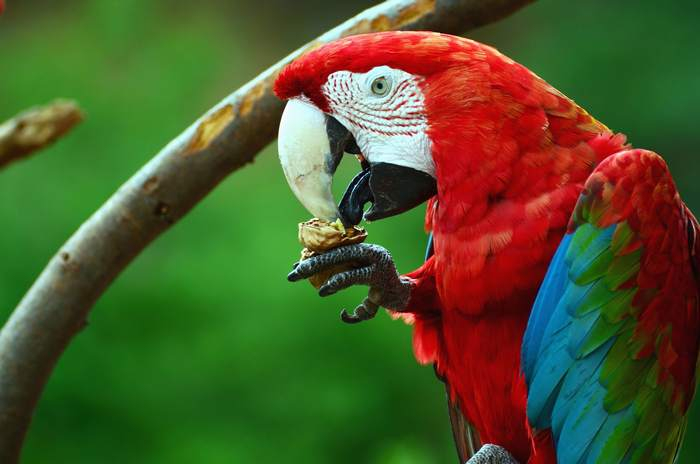

In [ ]:
img1

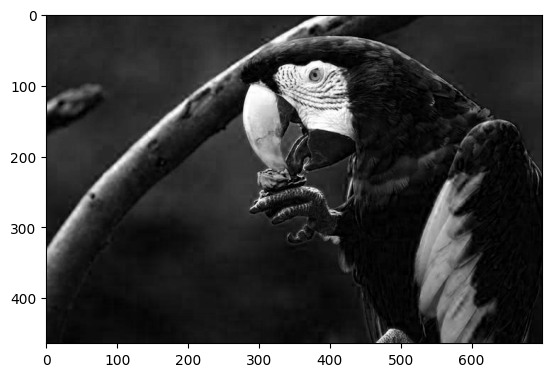

In [ ]:
plt.imshow(img1[:,:,2], cmap='gray')
plt.show()

In [ ]:
image_sum = img1.sum(axis=2)
new_image = image_sum / image_sum.max()

In [ ]:
print(img1.shape)
print(new_image.shape)

(464, 700, 3)
(464, 700)


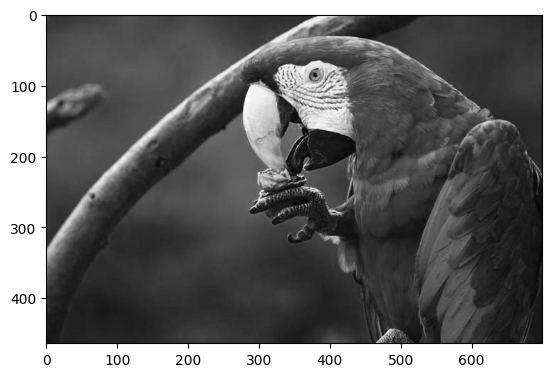

In [ ]:
plt.imshow(new_image, cmap='gray')
plt.show()

In [ ]:
# Aplicando PCA
pca_img = PCA_J(700)
pca_img.fit(new_image)

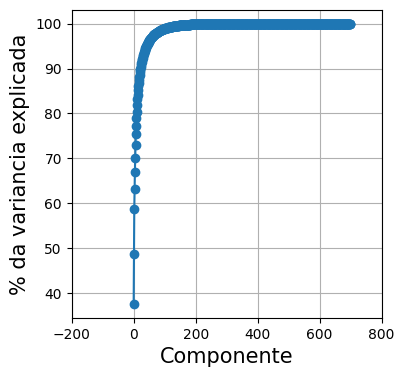

In [ ]:
component_analysis(pca_img.S, plot='varexp')

In [ ]:
X_proj = pca_img.transform(new_image)

In [ ]:
X_proj.shape

(464, 700)

In [ ]:
k_proj = 300
X_rec = X_proj[:, :k_proj].dot(pca_img.princip_comp[:,:k_proj].T)

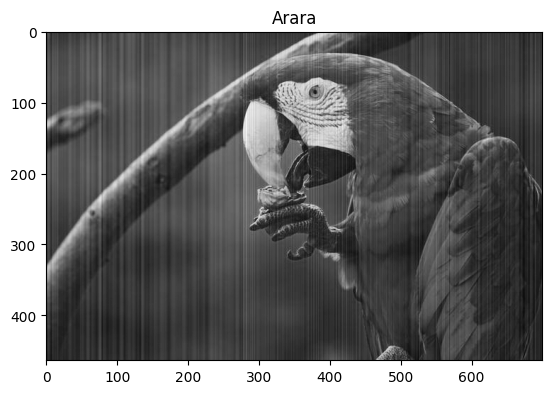

In [ ]:
plt.imshow(X_rec, cmap='gray')
plt.title('Arara')
plt.show()

Number of components explaining 95% variance: 41


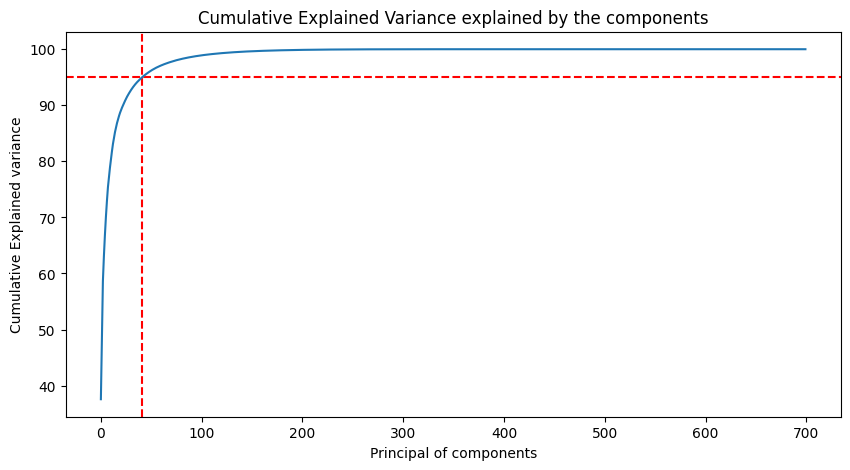

In [ ]:
var_cumu = (np.cumsum(pca_img.S) / np.sum(pca_img.S))*100

k=np.argmax(var_cumu>95)
print('Number of components explaining 95% variance: '+str(k))

plt.figure(figsize=[10,5])
plt.title('Cumulative Explained Variance explained by the components')
plt.ylabel('Cumulative Explained variance')
plt.xlabel('Principal of components')
plt.axvline(x=k, color='r', linestyle='--')
plt.axhline(y=95, color='r', linestyle='--')
ax = plt.plot(var_cumu)



In [ ]:
def plot_at_k(k):
  X_rec = X_proj[:, :k].dot(pca_img.U[:,:k].T)
  plt.imshow(X_rec, cmap='gray')
  plt.title('Arara')
  plt.show()


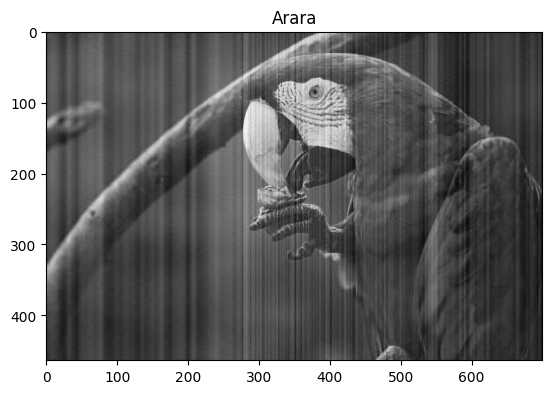

In [ ]:
plot_at_k(100)

In [ ]:
# Define the plot_at_k function to plot on a specific axes object
def plot_at_k(k):
    X_rec = X_proj[:, :k].dot(pca_img.U[:,:k].T)  # Reconstruct the image
    return X_rec

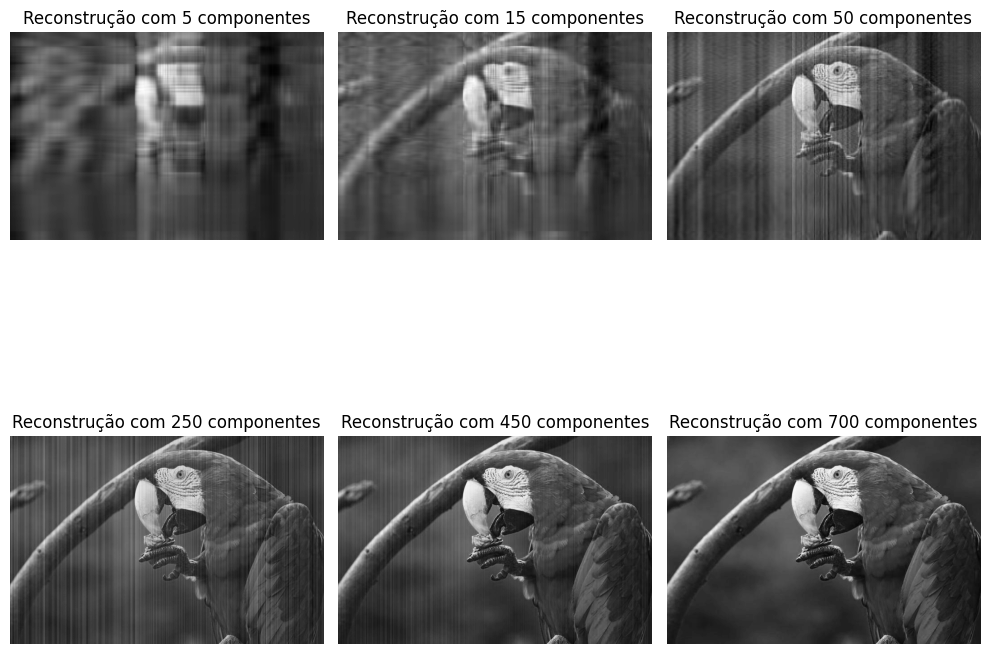

In [ ]:
ks =[5, 15, 50, 250, 450, 700]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10),tight_layout=True)
axes = axes.flatten()

for ax, file in zip(axes, ks):
  pic = plot_at_k(file)
  ax.imshow(pic, cmap='gray')
  ax.set_title(f'Reconstrução com {file} componentes')
  ax.axis('off')

plt.show()


In [ ]:
U, S, V = np.linalg.svd(new_image)

In [ ]:
S = np.diag(S)

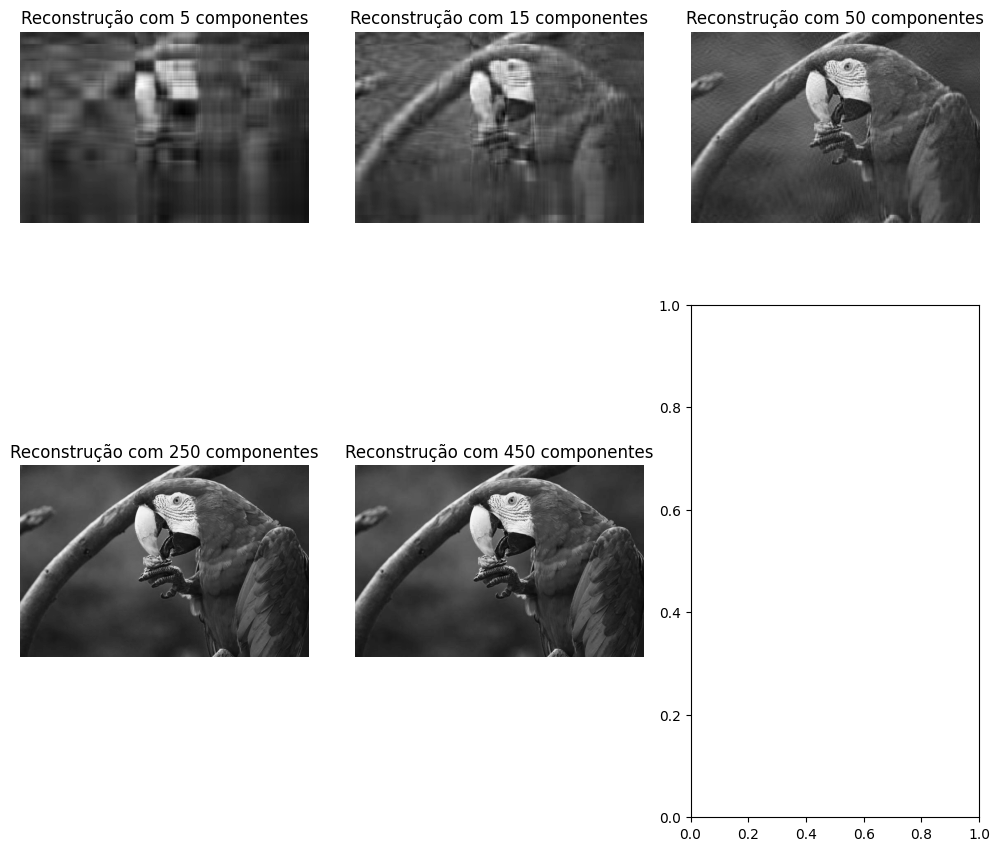

In [ ]:
ks =[5, 15, 50, 250, 450]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10),tight_layout=True)
axes = axes.flatten()

for ax, r in zip(axes, ks):
  pic = U[:,:r] @ S[0:r,:r] @ (V[:r,:])
  ax.imshow(pic, cmap='gray')
  ax.set_title(f'Reconstrução com {r} componentes')
  ax.axis('off')

plt.show()
